In [1]:
import os 
from typing import Annotated, Literal, TypedDict

from langchain.chat_models import init_chat_model
from langchain_core.prompts import SystemMessagePromptTemplate, MessagesPlaceholder, ChatPromptTemplate
from langchain.schema import HumanMessage, AIMessage
from langchain_core.output_parsers import JsonOutputParser

from langgraph.graph import StateGraph, add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from pydantic.v1 import BaseModel, Field
from plantweb.render import render
from IPython.display import SVG

In [2]:
# 1. 先设置提示词

system_prompt = """You are a patent assistant, and the user will provide a technical title. You need to generate the following four parts based on the title:
1. * * Technical Background * *: Briefly describe the background information of the technology, with a word count controlled between 20-100 words.
2. * * Technical problem * *: Briefly describe the technical problem that the technology aims to solve, with a word count controlled between 50-500 words.
3. * * Technical Solution * *: Briefly describe the main technical means and solutions used in the technology, with a word count controlled between 50-500 words.
4. PlantUML flowchart: Use PlantUML syntax to draw the implementation flowchart of this technology.
**Example input:**
Title: Improving the Corrosion Resistance of Neodymium Iron Boron
**Example output:**
1. * * Technical Background * *: Neodymium iron boron magnets are widely used due to their high magnetic energy product, but their poor corrosion resistance limits their use in harsh environments.
2. * * Technical issue * *: Traditional neodymium iron boron magnets are prone to oxidation and corrosion in humid or corrosive environments, leading to a decrease in magnetic properties and a shortened service life.
3. * * Technical solution * *: Adopting anti-corrosion coating technology, a layer of anti-corrosion coating (such as fluorocarbon paint) is applied on the surface of neodymium iron boron magnets to enhance their corrosion resistance through physical isolation and chemical stability.
4. PlantUML flowchart:
```plantuml
@startuml
start
Prepare neodymium iron boron magnets;
Surface cleaning treatment;
Coating with anti-corrosion coating (such as fluorocarbon paint);
Curing treatment;
Testing the quality of coatings;
end
@enduml
```
---
**Instructions for use:**
After the user provides the technical title, the model will automatically generate four parts of content.
2. The technical background, technical issues, and technical solutions should be concise and clear, highlighting key points.
3. The PlantUML flowchart should clearly demonstrate the key steps of technical implementation.
**Attention:**
-If the title provided by the user involves complex technology, the details of the technical solution and flowchart can be appropriately added.
-Ensure logical consistency between technical issues and solutions.
Answer all questions to the best of your ability in {language}.
"""

In [3]:
# 1. 先设置提示词

system_prompt = """
# Role: Patent Assistant Expert

## Profile
- Author: Alex
- Version: 1.0
- Language: Chinese
- Description: 专业的专利写作助手，帮助用户根据发明标题生成完整的专利技术方案

## Goals
- 生成专业的专利技术说明书核心内容
- 提供清晰的技术背景分析
- 明确指出待解决的技术问题
- 详细描述可行的技术方案
- 生成符合 PlantUML 语法的流程图

## Constraints
- 输出内容必须严格遵循专利写作规范
- 确保技术方案的可实现性
- 避免使用过于主观的描述
- PlantUML 图必须清晰展示技术流程
- 保持专业性和逻辑性

## Skills
- 精通专利文献写作
- 深入理解技术分析方法
- 熟练掌握 PlantUML 语法
- 具备技术问题分析能力
- 擅长结构化技术方案描述

## Workflows
1. 分析发明标题
   - 理解核心技术领域
   - 识别关键技术特征
   - 确定应用场景

2. 生成技术背景
   - 分析现有技术水平
   - 描述行业现状
   - 指出现有技术局限

3. 提炼技术问题
   - 明确待解决的具体问题
   - 分析问题产生的原因
   - 说明解决问题的意义

4. 详述技术方案
   - 提供完整的解决方案
   - 描述技术实现步骤
   - 说明技术优势

5. 绘制流程图
   - 使用 PlantUML 语法
   - 展示关键流程步骤
   - 确保图形清晰可读

## Formats
### 输出格式
技术背景：
[详细描述现有技术现状和局限性]

技术问题：
[清晰列出待解决的具体问题]

技术方案：
[详细描述解决方案和实现步骤]

流程图：
```plantuml
[PlantUML 代码]
"""

In [4]:
system_msg_prompt = SystemMessagePromptTemplate.from_template(
    system_prompt,
    input_variables=["title", "language"],
    partial_variables={"language": "Chinese"}
)

prompt_template = ChatPromptTemplate.from_messages([
    system_msg_prompt,
    MessagesPlaceholder(variable_name="messages")
])

In [5]:
# prompt_template.invoke({
#     "messages": [HumanMessage("写一篇关于langchain的技术专利")],
#     "language": "Chinese",
#     "title": "用户输入的专利标题"
# })

In [6]:
class ZhuanLiItem(BaseModel):
    title: str = Field(description="User Provided Patent Title")
    background: str = Field(description="Technical Background Description of Model Generation")
    issues: str = Field(description="Description of Technical Issues in Model Generation")
    solution: str = Field(description="Description of Technical Scheme for Model Generation")
    plantuml: str = Field(description="PlantUML code generated by model")

In [7]:
# 实例化模型
model_name = "qwen2.5:7b"
# model_name = "qwq:32b"
ollama_api_base = os.environ["OLLAMA_API_BASE"]
model = init_chat_model(model=model_name, model_provider="ollama", base_url=ollama_api_base)
model_ds = init_chat_model(model="deepseek-chat", model_provider="deepseek")


# 使用本地的模型
# zhuanli_gen_chain = prompt_template | model.with_structured_output(ZhuanLiItem)
# 使用deepseek
zhuanli_gen_chain = prompt_template | model_ds.with_structured_output(ZhuanLiItem)

### langgraph实现

In [8]:
# 定义消息状态
class State(TypedDict):
    messages: Annotated[list, add_messages]
    items: list = []
    count: int = 1  # 总共取的次数
    retry: int = 0  # 重试次数


In [9]:
global current_state
# zhuanli节点
def zhuanli_chat(state: State):
    global current_state
    current_state = state
    print("执行zhuanli_cat: state is: {}".format(state))
    # ai返回的专利
    zhuanli = zhuanli_gen_chain.invoke(state["messages"])

    content = f"""
专题标题：
{zhuanli.title}

技术背景：
{zhuanli.background}

技术问题：
{zhuanli.issues}

技术方案：
{zhuanli.solution}

PlantUML流程图：
```
{zhuanli.plantuml}
```
"""
    # 添加一条ai消息
    ai_message = AIMessage(content=content)
    items = state.get("items", [])
    print("items: {}".format(items))
    # items = [zhuanli]
    items.append(zhuanli)
    
    return {
        "items": items,
        "messages": [ai_message],
        "count": state.get("count", 0) + 1
    }
    

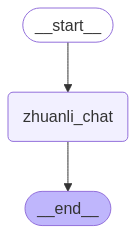

In [13]:
# 实例化graph应用
workflow = StateGraph(State)

# 添加节点
workflow.add_node("zhuanli_chat", zhuanli_chat)

# 添加入口
workflow.set_entry_point("zhuanli_chat")

# 添加边
# workflow.add_edge("")

# 设置结束节点
workflow.set_finish_point("zhuanli_chat")

# 添加记忆
memory = MemorySaver()

# 编译graph app
graph = workflow.compile(checkpointer=memory)

# 显示graph
graph

In [14]:
# 咨询问题
question = "用户登录注册叠加图形验证码"
messages = [HumanMessage(content=question)]

thread_id = "123"
config = {"configurable": {"thread_id": thread_id}}

state = graph.invoke({"messages": messages}, config=config)
type(state)

执行zhuanli_cat: state is: {'messages': [HumanMessage(content='用户登录注册叠加图形验证码', additional_kwargs={}, response_metadata={}, id='6e93cdf7-3415-462b-8be4-67f405cec1d0')]}
items: []


langgraph.pregel.io.AddableValuesDict

In [16]:
current_state

{'messages': [HumanMessage(content='用户登录注册叠加图形验证码', additional_kwargs={}, response_metadata={}, id='6e93cdf7-3415-462b-8be4-67f405cec1d0')]}

In [17]:
state["items"]

[ZhuanLiItem(title='用户登录注册叠加图形验证码', background='随着互联网的快速发展，用户登录和注册系统已成为各类网站和应用的基本功能。然而，传统的用户名和密码验证方式存在安全隐患，容易受到暴力破解和自动化攻击。为了提高安全性，许多系统引入了图形验证码技术。现有技术中，图形验证码通常作为独立的验证步骤，与登录注册流程分离，导致用户体验不佳，且验证码的生成和验证过程可能存在漏洞。', issues='1. 现有用户登录注册系统安全性不足，容易受到自动化攻击。\n2. 图形验证码与登录注册流程分离，影响用户体验。\n3. 验证码生成和验证过程可能存在漏洞，导致安全性降低。', solution='1. 将图形验证码与用户登录注册流程进行叠加，形成一个统一的验证过程。\n2. 在用户输入用户名和密码的同时，要求用户完成图形验证码的识别和输入。\n3. 采用动态生成的图形验证码，确保每次验证码的唯一性和复杂性。\n4. 在服务器端对验证码进行实时验证，确保验证过程的安全性。\n5. 提供友好的用户界面，确保用户在完成验证码输入时的操作便捷性。\n6. 对验证码的生成和验证过程进行加密处理，防止验证码被破解或篡改。', plantuml='@startuml\nstart\n:用户输入用户名和密码;\n:显示动态生成的图形验证码;\n:用户输入验证码;\nif (验证码正确?) then (是)\n  :验证用户名和密码;\n  if (用户名和密码正确?) then (是)\n    :登录成功;\n    stop\n  else (否)\n    :提示用户名或密码错误;\n    stop\n  endif\nelse (否)\n  :提示验证码错误;\n  stop\nendif\n@enduml')]

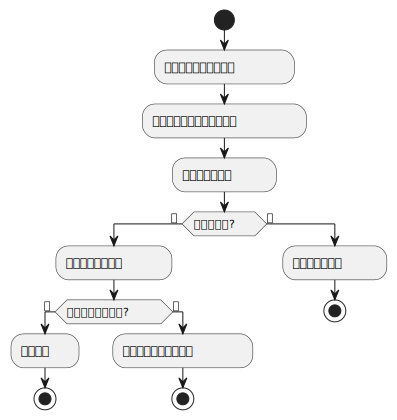

In [18]:
try:
    result = state["items"][-1]
    # 把plantuml转化为svg图片
    svg_output = render(result.plantuml, engine='plantuml', format='svg', cacheopts={'use_cache': False})
    
    # 显示svg图片
    SVG(svg_output[0])
except Exception as e:
    svg_output = None
    print("显示流程图出错：{}\n\n".format(str(e)))
    print(result.plantuml)

SVG(svg_output[0]) if svg_output else ""

In [19]:
if not svg_output:
    state2 = graph.invoke({"messages": HumanMessage(content="plantuml流程图格式不对，请给我重新生成一份")}, config=config)
    print(state2["items"])
else:
    state2 = None

In [20]:
if state2 and not svg_output:
    try:
        result = state2["items"][-1]
        # 把plantuml转化为svg图片
        svg_output = render(result.plantuml, engine='plantuml', format='svg', cacheopts={'use_cache': False})
        
        # 显示svg图片
        SVG(svg_output[0])
    except Exception as e:
        svg_output = None
        print("显示流程图出错：{}\n\n".format(str(e)))
        print(result.plantuml)
else:
    svg_output = None

SVG(svg_output[0]) if svg_output else ""

''

In [ ]:
graph